In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'DejaVu Sans'
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

pd.set_option("display.max_colwidth", None)

In [2]:
def plot_pca(
    norm_counts: pd.DataFrame,
    meta_tab: pd.DataFrame,
    outdir: str = None,
    prefix: str = "pca",
    save: bool = False,
    annotate: str = "centroid"
):

    if "feature_id" in norm_counts.columns:
        norm_counts = norm_counts.set_index("feature_id")

    meta_tab = meta_tab.copy()
    meta_tab["group"] = meta_tab["group"].astype(str).astype("category")
    meta_tab = meta_tab.set_index("sample").loc[norm_counts.columns].reset_index()

    # PCA
    pca = PCA()
    coords = pca.fit_transform(norm_counts.T)

    pca_coords = pd.DataFrame(
        coords,
        index=norm_counts.columns,
        columns=[f"PC{i+1}" for i in range(coords.shape[1])]
    ).reset_index().rename(columns={"index": "sample"})

    var_exp = pca.explained_variance_ratio_ * 100
    pca_coords["group"] = meta_tab["group"].values

    # ---------------------------
    # Custom label + color mapping
    # ---------------------------
    dic = {
    "6SL_120": r"6SL $_{\mathbf{OD(0.120)}}$",
    "6SL_400": r"6SL $_{\mathbf{OD(0.400)}}$",
    "Lactose_120": r"Lactose $_{\mathbf{OD(0.120)}}$",
    "Lactose_400": r"Lactose $_{\mathbf{OD(0.400)}}$",
    "LNnT_120": r"LNnT $_{\mathbf{OD(0.120)}}$",
    "LNnT_400": r"LNnT $_{\mathbf{OD(0.400)}}$"
}

  
    dic_colors = {
        "6SL_120":"xkcd:baby blue",
        "6SL_400":"xkcd:bright blue",
        "Lactose_120":"xkcd:dusky pink",
        "Lactose_400":"xkcd:red pink",
        "LNnT_120":"xkcd:soft green",
        "LNnT_400":"#087804"
    }

    # map labels + colors
    pca_coords["label"] = pca_coords["group"].map(dic)
    group_colors = {g: dic_colors[g] for g in pca_coords["group"].unique()}

    sns.set(style="white")

    fig, ax = plt.subplots(figsize=(7, 6))

    # ---------------------------
    # Scatter with alpha fill and solid edges
    # ---------------------------
    # Soft fill
    ax.scatter(
        pca_coords["PC1"],
        pca_coords["PC2"],
        s=140,
        c=[group_colors[g] for g in pca_coords["group"]],
        alpha=0.7,
        edgecolors='none'
    )

    # Solid edges
    for g in pca_coords["group"].unique():
        mask = pca_coords["group"] == g
        ax.scatter(
            pca_coords.loc[mask, "PC1"],
            pca_coords.loc[mask, "PC2"],
            s=140,
            facecolors='none',
            edgecolors=group_colors[g],
            linewidths=1.5,
            alpha=1
        )

    # optional "+" overlay
#    ax.scatter(
#        pca_coords["PC1"],
#        pca_coords["PC2"],
#        marker="+",
#        c=[group_colors[g] for g in pca_coords["group"]],
#        s=160,
#        linewidths=2
#    )

    # ---------------------------
    # Annotation
    # ---------------------------
    if annotate == "centroid":
        centroids = (
            pca_coords
            .groupby("group")[["PC1", "PC2"]]
            .mean()
        )

        for group, (x, y) in centroids.iterrows():
            ax.text(
                x,
                y + 0.8,
                dic[group],
                fontsize=12,
                weight="bold",
                ha="center",
                va="bottom",
                color=dic_colors[group]
            )

    elif annotate == "points":
        for _, row in pca_coords.iterrows():
            ax.text(
                row["PC1"],
                row["PC2"] + 0.5,
                row["label"],
                fontsize=9,
                ha="center",
                color=dic_colors[row["group"]]
            )

    # ---------------------------
    # Axes
    # ---------------------------
    ax.set_xlabel(f"PC1: {var_exp[0]:.1f}% variance", fontsize=14)
    ax.set_ylabel(f"PC2: {var_exp[1]:.1f}% variance", fontsize=14)

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)

    # Ensure ticks are visible
    ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        length=6,
        width=1,
        color='black',
        bottom=True,
        left=True,
        labelsize=14
    )

    sns.despine(ax=ax, trim=False)

    # limits
    x = pca_coords["PC1"]
    y = pca_coords["PC2"]
    xpad = (x.max() - x.min()) * 0.08
    ypad = (y.max() - y.min()) * 0.08
    ax.set_xlim(x.min() - xpad, x.max() + xpad)
    ax.set_ylim(y.min() - ypad, y.max() + ypad)

    # optional fixed limits (keep if needed)
    ax.set_xlim(-35, 35)
    ax.set_ylim(-20, 20)

    plt.tight_layout()

    # ---------------------------
    # Save
    # ---------------------------
    if save:
        os.makedirs(outdir, exist_ok=True)

        with open(os.path.join(outdir, f"{prefix}.pkl"), "wb") as f:
            pickle.dump(pca, f)

        pca_coords.to_csv(
            os.path.join(outdir, f"{prefix}_coords.tsv"),
            sep="\t",
            index=False
        )

        fig.savefig(
            os.path.join(outdir, f"{prefix}_grouped.png"),
            dpi=300,
            facecolor="white"
        )

    return fig, ax, pca, pca_coords

In [3]:
norm_counts_df = pd.read_csv("../../out/cpm_counts.tsv", sep="\t")
meta_df = pd.read_csv("../../data/samples.tsv", sep="\t")

/scratch/local/6390571/ipykernel_2039398/2066061907.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")[["PC1", "PC2"]]


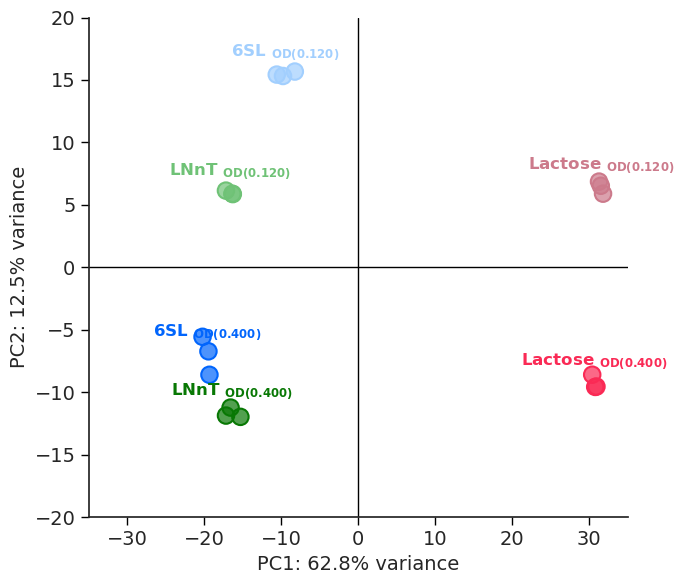

In [4]:
fig, ax, pca, coords = plot_pca(
    norm_counts_df,
    meta_df,
    annotate="centroid",
    outdir="../../out/figures/",
    prefix="PCA",
    save=True
)